# Exploratory Data Analysis

Initial Univariate and bivariate exploration of the KPIs built in the previous notebooks, including the funnel-level KPIs (step conversion rate, time per step).

**Sections**

**1. KPI Grain Reference**

**2. Setup and Helpers**

**3. Client-level KPIs**

-   **Completion Rate**
-   **Error Rate**
-   **Time to Completion**
-   **Sessions per Client**
-   **Average Steps per Client**

**4. Events-level KPIs**

   - **Step-Conversation Rate**
   - **Time Spent by Step**


## KPI grain reference

| KPI                  | Grain  | Definition                                                     |
|----------------------|--------|----------------------------------------------------------------|
| Completion Rate      | client | % of clients that reached `confirm`                            |
| Time to Completion   | client | average time from `start` to `confirm` (completed visits only) |
| Avg Steps per Client | client | average number of steps recorded in the visit                  |
| Error Rate           | client | % of clients with at least one backward step                   |
| Step Conversion Rate | event  | % of visits at step N that reached step N+1                    |
| Time Spent per Step  | event  | average duration users spend on each step                      |
| Sessions per Client  | client | distinct visits per client                                     |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, pearsonr, spearmanr
from scipy.stats.contingency import association

df_events = pd.read_csv("events_kpi_table.csv", parse_dates=["date_time"])
df_visits = pd.read_csv("visits_kpi_table.csv", parse_dates=["visit_start", "visit_end"])
df_clients = pd.read_csv("client_kpi_table.csv")

In [2]:
sns.set_theme(style="whitegrid")

def numeric_summary(df, cols=None):
    cols = cols or df.select_dtypes('number').columns.tolist()
    s = df[cols].describe().T
    s['skew'] = df[cols].skew()
    s['kurtosis'] = df[cols].kurtosis()
    s['missing_%'] = df[cols].isna().mean().mul(100)
    return s.round(3)

## Client-level KPIs

In [3]:
df_clients["completion_rate"].mean() * 100

np.float64(38.5267494602571)

In [4]:
#Completion Rate

completion_rate_final = df_clients.groupby('Variation')["completion_rate"].mean() * 100


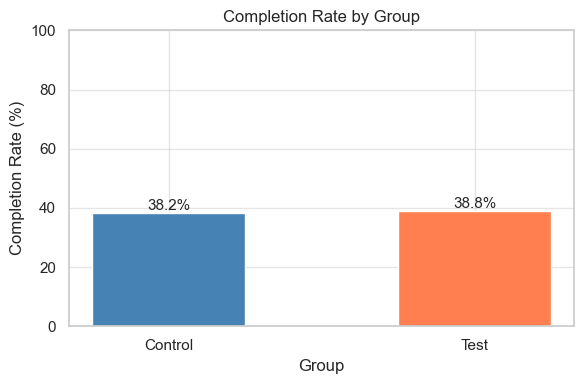

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(completion_rate_final.index, completion_rate_final.values, color=["steelblue", "coral"], width=0.5)

ax.set_title("Completion Rate by Group")
ax.set_xlabel("Group")
ax.set_ylabel("Completion Rate (%)")
ax.set_ylim(0, 100)

for i, val in enumerate(completion_rate_final.values):
    ax.text(i, val + 1, f"{val:.1f}%", ha="center", fontsize=11)

plt.tight_layout()
plt.show()

In [6]:
#Error Rate
print(df_clients["error_rate"].mean() * 100)
error_rate_final = df_clients.groupby('Variation')["error_rate"].mean() * 100


50.13963990730287


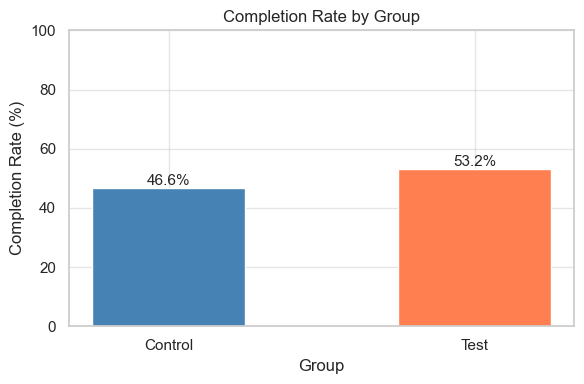

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(error_rate_final.index, error_rate_final.values, color=["steelblue", "coral"], width=0.5)

ax.set_title("Completion Rate by Group")
ax.set_xlabel("Group")
ax.set_ylabel("Completion Rate (%)")
ax.set_ylim(0, 100)

for i, val in enumerate(error_rate_final.values):
    ax.text(i, val + 1, f"{val:.1f}%", ha="center", fontsize=11)

plt.tight_layout()
plt.show()

Variation
Control    1.370186
Test       1.379400
Name: session_per_client, dtype: float64


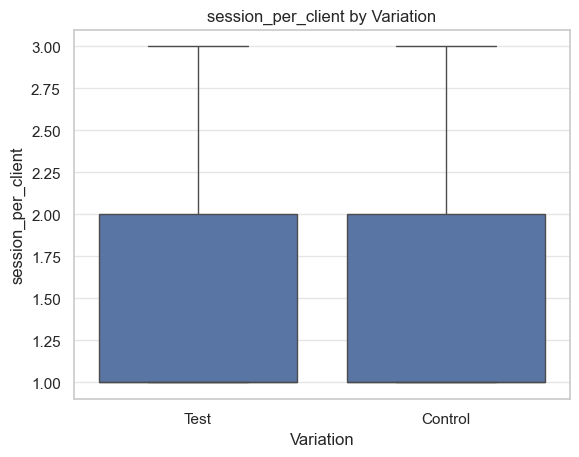

In [8]:
# Sessions per Client

print(df_clients.groupby('Variation')["session_per_client"].mean())

sns.boxplot(data=df_clients, x='Variation', y="session_per_client", showfliers=False)
plt.title(f'{"session_per_client"} by Variation');
plt.show()

Variation
Control    4.696297
Test       5.075901
Name: avg_steps_client, dtype: float64


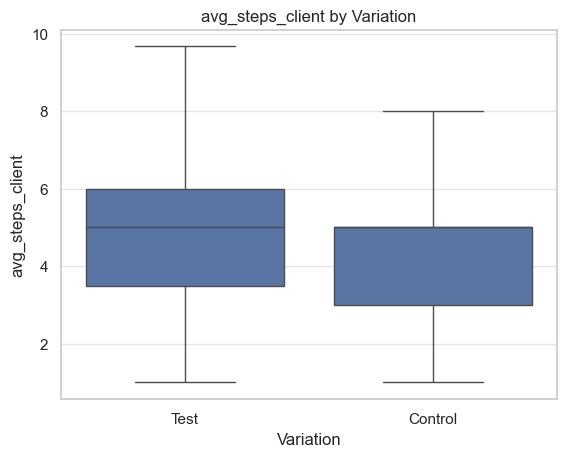

In [9]:
#Average Steps per Client

print(df_clients.groupby('Variation')["avg_steps_client"].mean())

sns.boxplot(data=df_clients, x='Variation', y="avg_steps_client", showfliers=False)
plt.title(f'{"avg_steps_client"} by Variation'); plt.show()

Variation
Control    289.899254
Test       248.067364
Name: avg_time_to_completion, dtype: float64


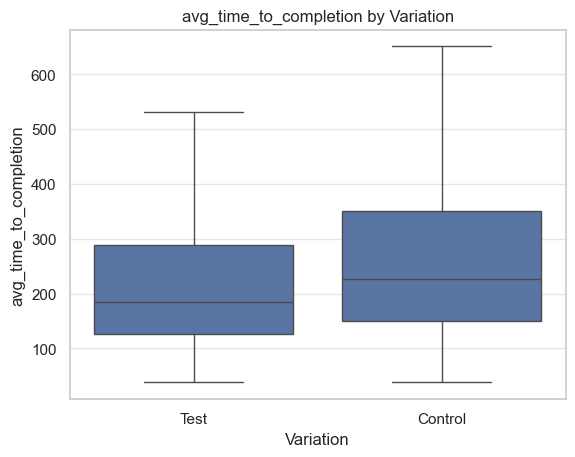

In [10]:
#Average Time to Completion

print(df_clients.groupby('Variation')["avg_time_to_completion"].mean())

sns.boxplot(data=df_clients, x='Variation', y="avg_time_to_completion", showfliers=False)
plt.title(f'{"avg_time_to_completion"} by Variation'); plt.show()

## Visit-level KPIs

In [11]:
if 'Variation' not in df_events.columns:
    df_events = df_events.merge(df_clients[['client_id', 'Variation']],
                                on='client_id', how='left')

In [12]:
#Step Conversion Rate

step_order = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

funnel = df_events.groupby('process_step')['visit_id'].nunique().reindex(step_order).reset_index(name='n_visits')

funnel['conversion_rate'] = funnel['n_visits'] / funnel['n_visits'].shift(1)

funnel

,process_step,n_visits,conversion_rate
0,start,144902,NaN
1,step_1,119255,0.823005
2,step_2,104341,0.874940
3,step_3,95093,0.911368
4,confirm,89826,0.944612


In [13]:
parts = []
for variation, sub in df_events.groupby('Variation'):
    f = (sub.groupby('process_step')['visit_id'].nunique()
            .reindex(step_order)
            .reset_index(name='n_visits'))
    f['conversion_rate'] = (f['n_visits'] / f['n_visits'].shift(1)) * 100
    f['Variation'] = variation
    parts.append(f)

funnel_var = pd.concat(parts, ignore_index=True)
funnel_var

,process_step,n_visits,conversion_rate,Variation
0,start,30903,NaN,Control
1,step_1,23541,76.177070,Control
2,step_2,20131,85.514634,Control
3,step_3,18293,90.869803,Control
4,confirm,16039,87.678347,Control
5,start,33144,NaN,Test
6,step_1,28274,85.306541,Test
7,step_2,24493,86.627290,Test
8,step_3,22180,90.556486,Test
9,confirm,21725,97.948602,Test


In [22]:
pivot = (funnel_var.pivot(index='process_step',
                          columns='Variation',
                          values='conversion_rate')
            .reindex(step_order))
pivot

Variation,Control,Test
process_step,,
start,NaN,NaN
step_1,76.177070,85.306541
step_2,85.514634,86.627290
step_3,90.869803,90.556486
confirm,87.678347,97.948602


In [23]:
pivot.to_csv('step_conversion_rate.csv')

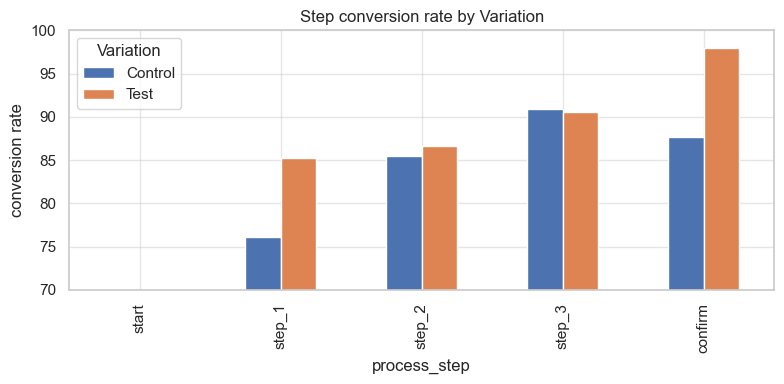

In [15]:
pivot[['Control', 'Test']].plot(kind='bar', figsize=(8, 4),
                                title='Step conversion rate by Variation')
plt.ylabel('conversion rate')
plt.ylim(70, 100)
plt.tight_layout(); plt.show()

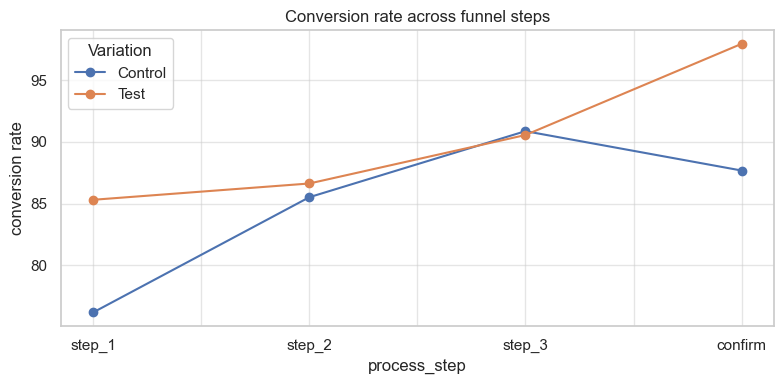

In [16]:
pivot[['Control', 'Test']].plot(kind='line', marker='o', figsize=(8, 4),
                                title='Conversion rate across funnel steps')
plt.ylabel('conversion rate'); plt.tight_layout(); plt.show()

In [24]:
#Average Time Spent per Step

time_per_step = df_events[df_events["process_step"] != "confirm"].groupby('process_step')['time_on_each_step'].mean().reset_index()

time_per_step

,process_step,time_on_each_step
0,start,139.024150
1,step_1,39.439692
2,step_2,45.788994
3,step_3,99.382272


In [25]:
time_avg = (df_events[df_events['process_step'] != 'confirm']
              .groupby(['visit_id', 'process_step', 'Variation'])['time_on_each_step']
              .mean()
              .reset_index())

time_avg = time_avg.groupby(['Variation', 'process_step'])['time_on_each_step'] \
         .mean().unstack().round(2)

time_avg

process_step,start,step_1,step_2,step_3
Variation,,,,
Control,143.91,40.70,37.11,95.34
Test,142.98,33.63,41.76,93.59


In [26]:
time_avg.to_csv('avg_time_step.csv')

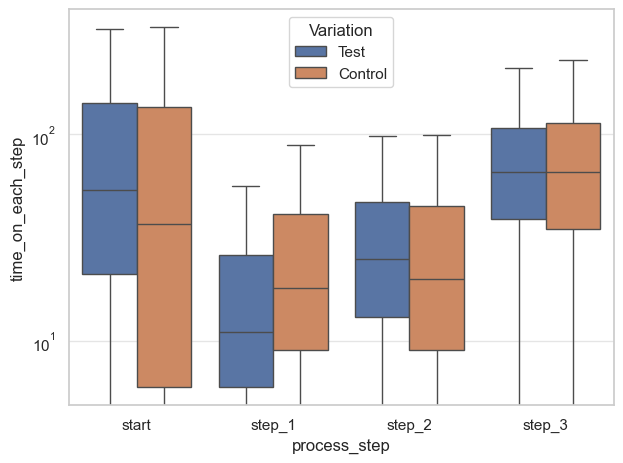

In [19]:
sns.boxplot(data=df_events[df_events['process_step'] != 'confirm'],
            x='process_step', y='time_on_each_step',
            hue='Variation', order=step_order[:-1], showfliers=False)
plt.yscale('log')
plt.tight_layout(); plt.show()

### Summary of findings

In [20]:
# 1. Define the edges of your buckets
# Example: 0-18, 19-30, 31-50, 51-100
bins = [0, 18, 30, 50, 100]

# 2. Define labels for the buckets
labels = ['Minor', 'Young Adult', 'Adult', 'Senior']

# 3. Create the new column
df_clients['age_group'] = pd.cut(df_clients['clnt_age'], bins=bins, labels=labels)



df_result = df_clients.groupby('Variation')['logons_6_mnth'].mean()


df_result




Variation
Control    6.166242
Test       6.101851
Name: logons_6_mnth, dtype: float64